In [496]:
import numpy as np
import pandas as pd

### Loading the data


In [497]:
df = pd.read_csv(r"C:\Users\akhil\Downloads\EV Charging Behavior Dataset.csv")

In [498]:
df

,User_ID,Age,City_Tier,EV_Type,Battery_Capacity_kWh,Charging_Sessions_Per_Month,Avg_Charge_Cost,Distance_Travelled_Per_Month,Income_Level,Loan_Taken,Missed_Payments_Last_6M,Tenure_Months,Charging_Location_Type,App_Usage_Score,Charger_Working_Status,Charging_Time_Minutes,High_Default_Risk,Charging_Efficiency_Index
0,1,59,Tier3,5KW,40.7,19,325.10,1702,Low,0,2,1,Public,1,Working,58.5,0,100.00
1,2,49,Tier5,5KW,31.7,9,439.97,2377,High,0,0,1,Highway,7,Working,47.0,0,96.36
2,3,35,Tier5,5KW,36.8,24,309.80,1905,Low,0,5,6,Highway,4,Working,53.5,1,100.00
3,4,63,Tier5,2KW,38.5,32,353.90,2074,Medium,0,1,31,Highway,1,Not Working,112.0,1,57.96
4,5,28,Tier1,5KW,33.2,8,597.43,1212,Medium,0,2,24,Private,6,Working,58.0,0,84.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18941,18942,54,Tier5,2KW,38.0,23,420.80,938,High,0,0,16,Highway,8,Working,58.0,0,100.00
18942,18943,47,Tier3,5KW,28.6,29,555.51,1289,High,1,1,28,Highway,1,Working,39.8,1,100.00
18943,18944,59,Tier2,5KW,28.6,17,500.97,577,Medium,0,5,15,Private,3,Working,34.3,0,100.00
18944,18945,64,Tier2,4KW,42.3,30,417.63,2255,Low,0,1,18,Highway,2,Working,65.3,1,100.00


### EDA on the Dataset

In [499]:
df.isnull().sum()

User_ID                         0
Age                             0
City_Tier                       0
EV_Type                         0
Battery_Capacity_kWh            0
Charging_Sessions_Per_Month     0
Avg_Charge_Cost                 0
Distance_Travelled_Per_Month    0
Income_Level                    0
Loan_Taken                      0
Missed_Payments_Last_6M         0
Tenure_Months                   0
Charging_Location_Type          0
App_Usage_Score                 0
Charger_Working_Status          0
Charging_Time_Minutes           0
High_Default_Risk               0
Charging_Efficiency_Index       0
dtype: int64

In [500]:
df.duplicated().sum()

0

In [501]:
df = df.drop(columns=['User_ID'],axis=1)

In [502]:
num_cols = df.select_dtypes(include=['int','float']).columns
num_cols
len(num_cols)

12

In [503]:
cat_cols = df.select_dtypes(exclude=['int','float']).columns
cat_cols
len(cat_cols)

5

In [504]:
for i in num_cols:
    print(i,df[i].skew())

Age 0.016500240041719034
Battery_Capacity_kWh -0.03799219751352503
Charging_Sessions_Per_Month 0.012409296653474367
Avg_Charge_Cost 0.011051143881667062
Distance_Travelled_Per_Month -0.00414249336292122
Loan_Taken 0.3733032910746641
Missed_Payments_Last_6M 0.010027044672049545
Tenure_Months -0.009439255378757326
App_Usage_Score -0.008810699279583844
Charging_Time_Minutes 1.8208130428800222
High_Default_Risk 0.22544129827507028
Charging_Efficiency_Index -2.191701539803105


In [505]:
for i in num_cols:
    print(i,df[i].kurt())

Age -1.1770016528527667
Battery_Capacity_kWh -0.026177680850988594
Charging_Sessions_Per_Month -1.1962139313810523
Avg_Charge_Cost -0.016146990768441505
Distance_Travelled_Per_Month -1.2038325116408075
Loan_Taken -1.860841100321303
Missed_Payments_Last_6M -1.263150090581646
Tenure_Months -1.2086166597548513
App_Usage_Score -1.2281868876072937
Charging_Time_Minutes 4.097739730771872
High_Default_Risk -1.9493820151410717
Charging_Efficiency_Index 3.6564236301924313


### Non Visual Univariate Analysis

In [506]:
for i in cat_cols:
    print(df[i].value_counts())
    print()

City_Tier
Tier5    5716
Tier3    4716
Tier1    3706
Tier2    2841
Tier4    1967
Name: count, dtype: int64

EV_Type
2KW    7654
5KW    5600
4KW    3832
3KW    1860
Name: count, dtype: int64

Income_Level
Medium    8586
Low       6614
High      3746
Name: count, dtype: int64

Charging_Location_Type
Highway    6450
Public     6303
Private    6193
Name: count, dtype: int64

Charger_Working_Status
Working        16094
Not Working     2852
Name: count, dtype: int64



In [507]:
for i in num_cols:
    print(df[i].value_counts())
    print()

Age
35    473
37    472
46    471
33    462
43    456
38    444
64    443
48    442
41    440
65    439
28    435
49    435
42    432
59    431
39    430
22    426
23    425
24    425
44    424
30    422
62    421
29    420
52    419
34    418
36    415
26    413
56    413
45    413
21    412
53    411
57    410
58    409
40    409
60    409
25    405
55    405
32    405
54    404
50    396
51    396
61    393
27    390
47    388
63    375
31    370
Name: count, dtype: int64

Battery_Capacity_kWh
33.5    91
34.5    90
34.1    89
31.1    88
33.2    86
        ..
65.7     1
63.7     1
2.5      1
5.0      1
7.3      1
Name: count, Length: 621, dtype: int64

Charging_Sessions_Per_Month
9     667
18    665
34    662
33    658
16    654
12    653
13    653
5     647
17    645
20    641
11    638
19    635
28    634
23    634
14    633
30    632
15    632
25    624
31    624
27    623
22    623
32    622
24    622
6     619
26    618
8     613
10    605
7     591
29    590
21    589
Name: cou

### Univariate Visual Analysis

In [508]:
import matplotlib.pyplot as plt
import seaborn as sns

In [509]:
num_cols

Index(['Age', 'Battery_Capacity_kWh', 'Charging_Sessions_Per_Month',
       'Avg_Charge_Cost', 'Distance_Travelled_Per_Month', 'Loan_Taken',
       'Missed_Payments_Last_6M', 'Tenure_Months', 'App_Usage_Score',
       'Charging_Time_Minutes', 'High_Default_Risk',
       'Charging_Efficiency_Index'],
      dtype='object')

#### Distribution of single numerical variable

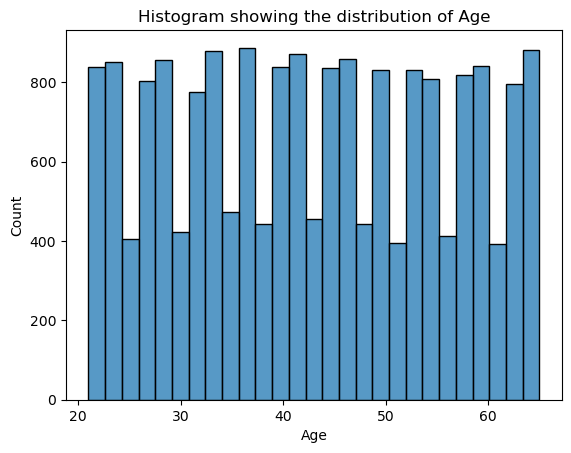

In [510]:
sns.histplot(data=df,x='Age')
plt.title('Histogram showing the distribution of Age');

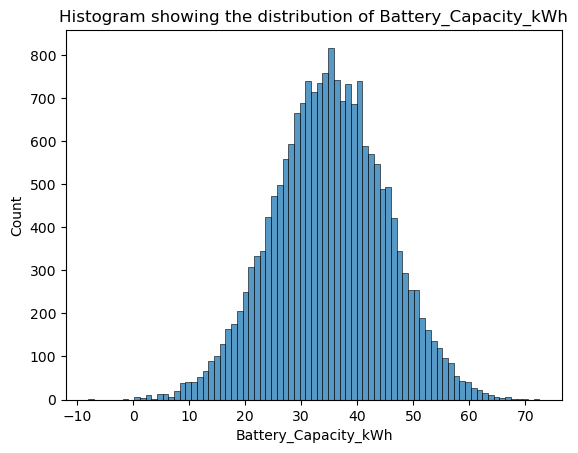

In [511]:
sns.histplot(data=df,x='Battery_Capacity_kWh')
plt.title('Histogram showing the distribution of Battery_Capacity_kWh');

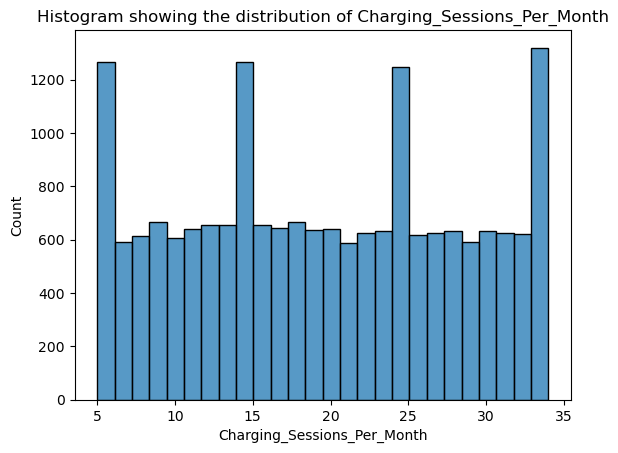

In [512]:
sns.histplot(data=df,x='Charging_Sessions_Per_Month')
plt.title('Histogram showing the distribution of Charging_Sessions_Per_Month');

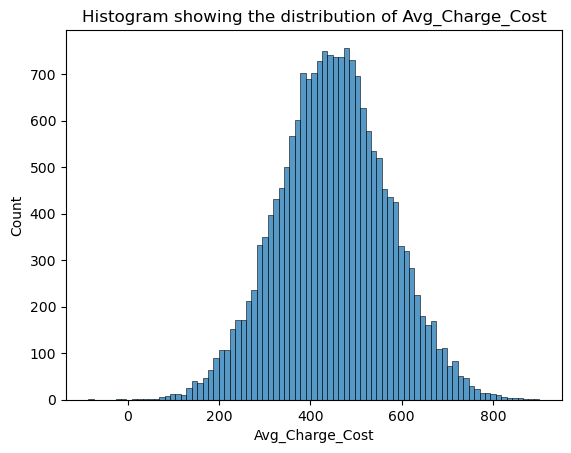

In [513]:
sns.histplot(data=df,x='Avg_Charge_Cost')
plt.title('Histogram showing the distribution of Avg_Charge_Cost');

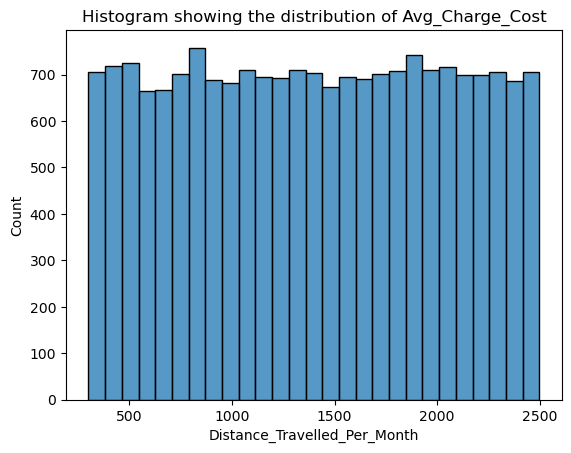

In [514]:
sns.histplot(data=df,x='Distance_Travelled_Per_Month')
plt.title('Histogram showing the distribution of Avg_Charge_Cost');

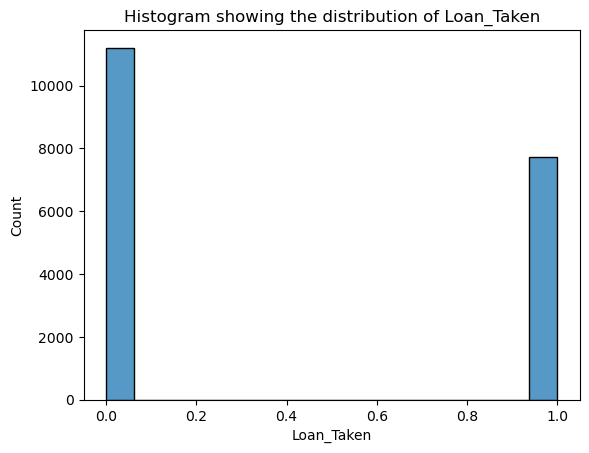

In [515]:
sns.histplot(data=df,x='Loan_Taken')
plt.title('Histogram showing the distribution of Loan_Taken');

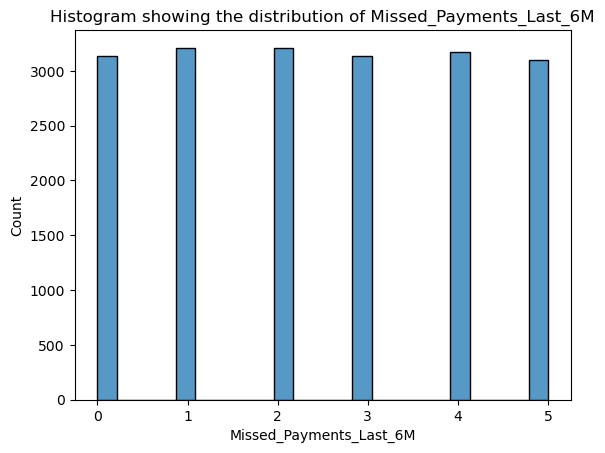

In [516]:
sns.histplot(data=df,x='Missed_Payments_Last_6M')
plt.title('Histogram showing the distribution of Missed_Payments_Last_6M');

In [517]:
num_cols

Index(['Age', 'Battery_Capacity_kWh', 'Charging_Sessions_Per_Month',
       'Avg_Charge_Cost', 'Distance_Travelled_Per_Month', 'Loan_Taken',
       'Missed_Payments_Last_6M', 'Tenure_Months', 'App_Usage_Score',
       'Charging_Time_Minutes', 'High_Default_Risk',
       'Charging_Efficiency_Index'],
      dtype='object')

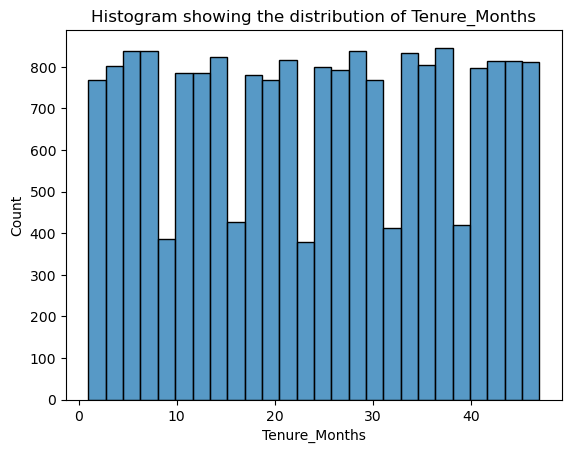

In [518]:
sns.histplot(data=df,x='Tenure_Months')
plt.title('Histogram showing the distribution of Tenure_Months');

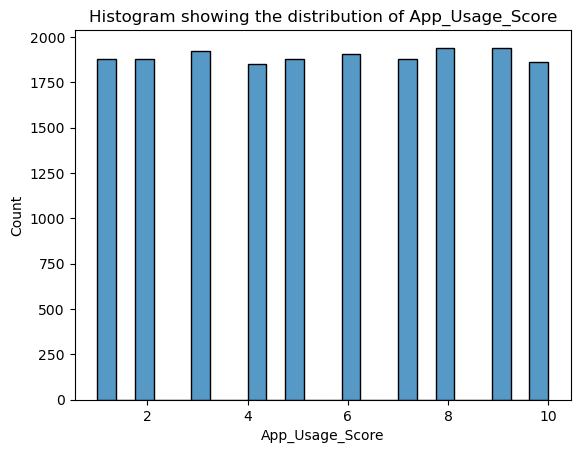

In [519]:
sns.histplot(data=df,x='App_Usage_Score')
plt.title('Histogram showing the distribution of App_Usage_Score');

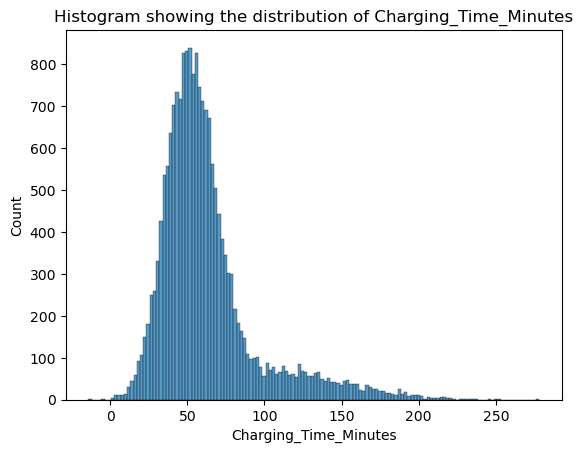

In [520]:
sns.histplot(data=df,x='Charging_Time_Minutes')
plt.title('Histogram showing the distribution of Charging_Time_Minutes');

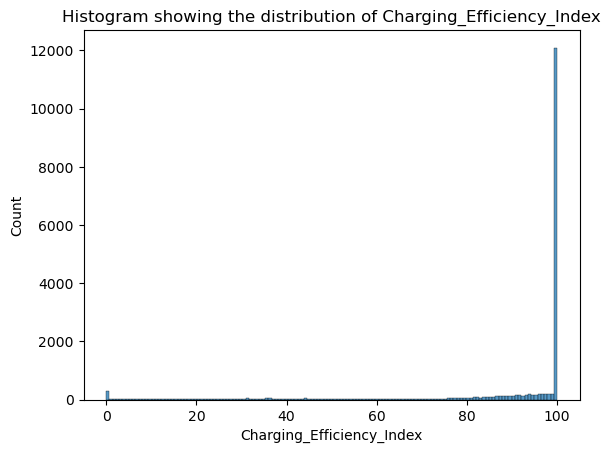

In [521]:
sns.histplot(data=df,x='Charging_Efficiency_Index')
plt.title('Histogram showing the distribution of Charging_Efficiency_Index');

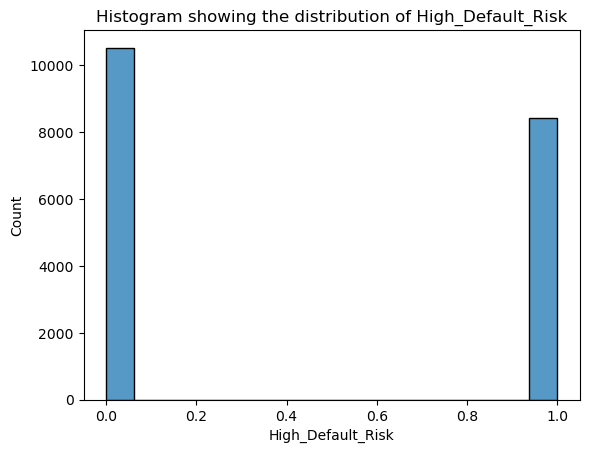

In [522]:
sns.histplot(data=df,x='High_Default_Risk')
plt.title('Histogram showing the distribution of High_Default_Risk');

#### Distribution of single categorical variable

In [523]:
cat_cols

Index(['City_Tier', 'EV_Type', 'Income_Level', 'Charging_Location_Type',
       'Charger_Working_Status'],
      dtype='object')

<Axes: xlabel='City_Tier', ylabel='count'>

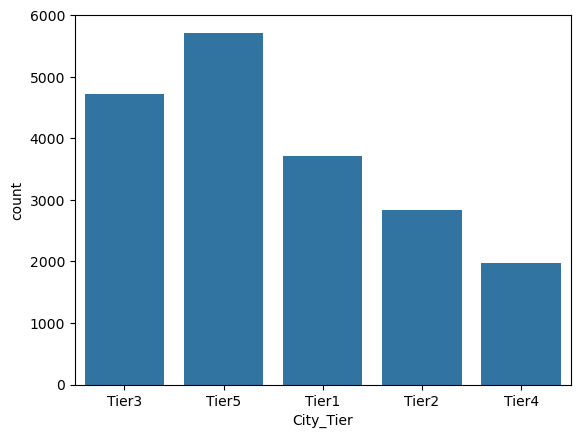

In [524]:
sns.countplot(data=df,x='City_Tier')

<Axes: xlabel='EV_Type', ylabel='count'>

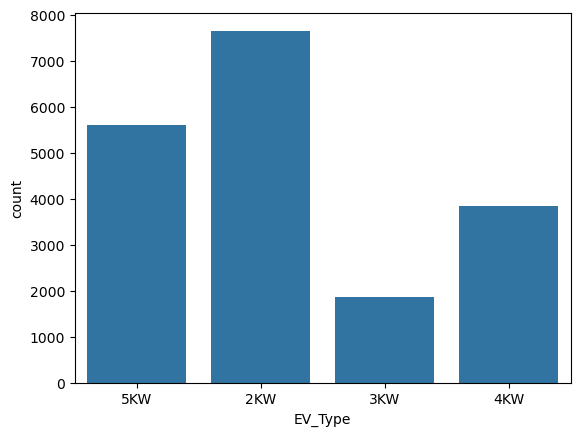

In [525]:
sns.countplot(data=df,x='EV_Type')

<Axes: xlabel='Income_Level', ylabel='count'>

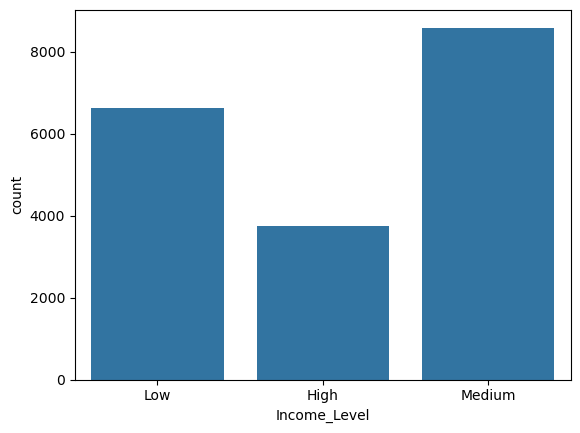

In [526]:
sns.countplot(data=df,x='Income_Level')

<Axes: xlabel='Charging_Location_Type', ylabel='count'>

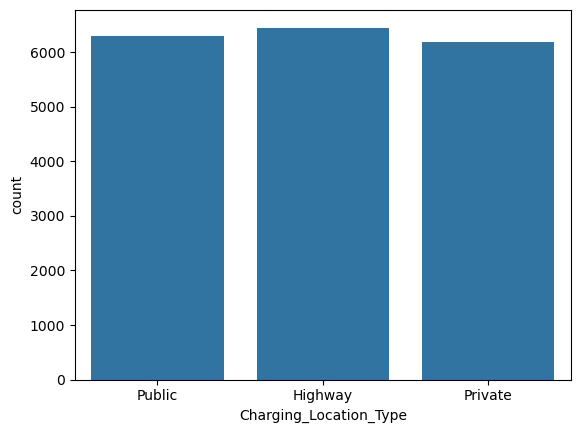

In [527]:
sns.countplot(data=df,x='Charging_Location_Type')

<Axes: xlabel='Charger_Working_Status', ylabel='count'>

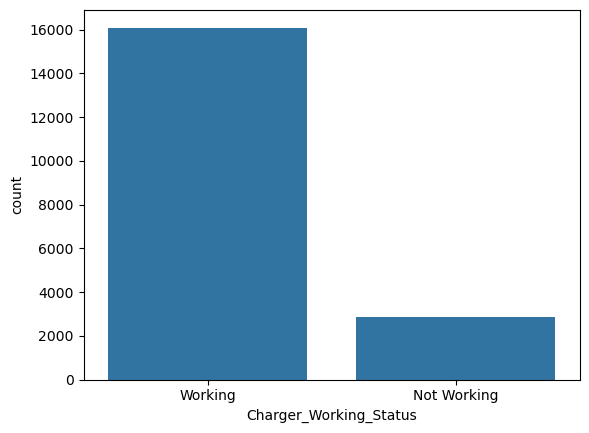

In [528]:
sns.countplot(data=df,x='Charger_Working_Status')

### Bivariate Visual Analysis

In [529]:
print(num_cols)
print(cat_cols)

Index(['Age', 'Battery_Capacity_kWh', 'Charging_Sessions_Per_Month',
       'Avg_Charge_Cost', 'Distance_Travelled_Per_Month', 'Loan_Taken',
       'Missed_Payments_Last_6M', 'Tenure_Months', 'App_Usage_Score',
       'Charging_Time_Minutes', 'High_Default_Risk',
       'Charging_Efficiency_Index'],
      dtype='object')
Index(['City_Tier', 'EV_Type', 'Income_Level', 'Charging_Location_Type',
       'Charger_Working_Status'],
      dtype='object')


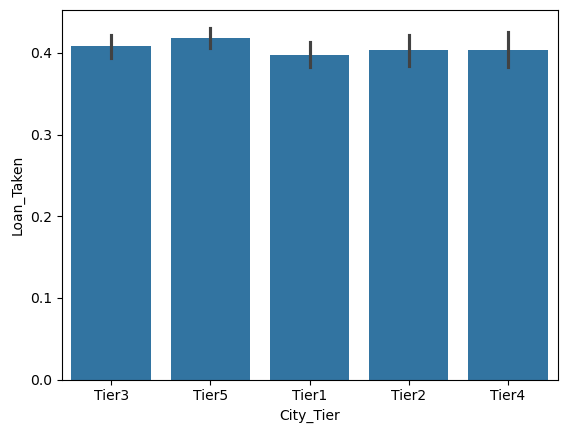

In [530]:
sns.barplot(data=df,x='City_Tier',y='Loan_Taken');

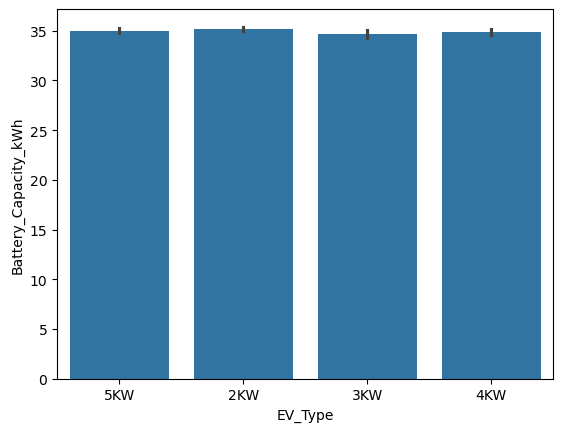

In [531]:
sns.barplot(data=df,x='EV_Type',y='Battery_Capacity_kWh');

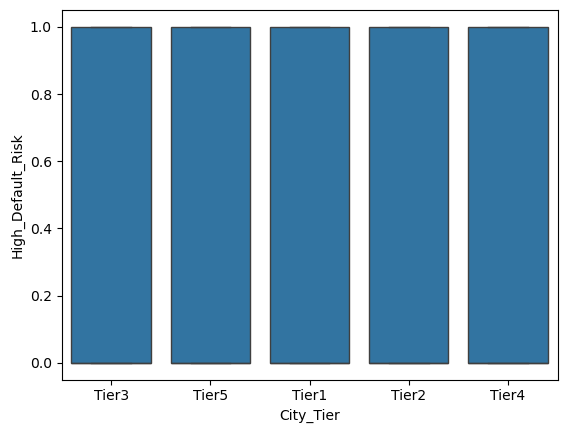

In [532]:
sns.boxplot(data=df,x='City_Tier',y='High_Default_Risk');

In [533]:
df

,Age,City_Tier,EV_Type,Battery_Capacity_kWh,Charging_Sessions_Per_Month,Avg_Charge_Cost,Distance_Travelled_Per_Month,Income_Level,Loan_Taken,Missed_Payments_Last_6M,Tenure_Months,Charging_Location_Type,App_Usage_Score,Charger_Working_Status,Charging_Time_Minutes,High_Default_Risk,Charging_Efficiency_Index
0,59,Tier3,5KW,40.7,19,325.10,1702,Low,0,2,1,Public,1,Working,58.5,0,100.00
1,49,Tier5,5KW,31.7,9,439.97,2377,High,0,0,1,Highway,7,Working,47.0,0,96.36
2,35,Tier5,5KW,36.8,24,309.80,1905,Low,0,5,6,Highway,4,Working,53.5,1,100.00
3,63,Tier5,2KW,38.5,32,353.90,2074,Medium,0,1,31,Highway,1,Not Working,112.0,1,57.96
4,28,Tier1,5KW,33.2,8,597.43,1212,Medium,0,2,24,Private,6,Working,58.0,0,84.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18941,54,Tier5,2KW,38.0,23,420.80,938,High,0,0,16,Highway,8,Working,58.0,0,100.00
18942,47,Tier3,5KW,28.6,29,555.51,1289,High,1,1,28,Highway,1,Working,39.8,1,100.00
18943,59,Tier2,5KW,28.6,17,500.97,577,Medium,0,5,15,Private,3,Working,34.3,0,100.00
18944,64,Tier2,4KW,42.3,30,417.63,2255,Low,0,1,18,Highway,2,Working,65.3,1,100.00


### Splitting the Data into features and Target

In [534]:
x = df.drop(columns=['High_Default_Risk'],axis=1)
y = df['High_Default_Risk']

In [535]:
x

,Age,City_Tier,EV_Type,Battery_Capacity_kWh,Charging_Sessions_Per_Month,Avg_Charge_Cost,Distance_Travelled_Per_Month,Income_Level,Loan_Taken,Missed_Payments_Last_6M,Tenure_Months,Charging_Location_Type,App_Usage_Score,Charger_Working_Status,Charging_Time_Minutes,Charging_Efficiency_Index
0,59,Tier3,5KW,40.7,19,325.10,1702,Low,0,2,1,Public,1,Working,58.5,100.00
1,49,Tier5,5KW,31.7,9,439.97,2377,High,0,0,1,Highway,7,Working,47.0,96.36
2,35,Tier5,5KW,36.8,24,309.80,1905,Low,0,5,6,Highway,4,Working,53.5,100.00
3,63,Tier5,2KW,38.5,32,353.90,2074,Medium,0,1,31,Highway,1,Not Working,112.0,57.96
4,28,Tier1,5KW,33.2,8,597.43,1212,Medium,0,2,24,Private,6,Working,58.0,84.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18941,54,Tier5,2KW,38.0,23,420.80,938,High,0,0,16,Highway,8,Working,58.0,100.00
18942,47,Tier3,5KW,28.6,29,555.51,1289,High,1,1,28,Highway,1,Working,39.8,100.00
18943,59,Tier2,5KW,28.6,17,500.97,577,Medium,0,5,15,Private,3,Working,34.3,100.00
18944,64,Tier2,4KW,42.3,30,417.63,2255,Low,0,1,18,Highway,2,Working,65.3,100.00


In [536]:
y

0        0
1        0
2        1
3        1
4        0
        ..
18941    0
18942    1
18943    0
18944    1
18945    0
Name: High_Default_Risk, Length: 18946, dtype: int64

#### Preprocessing on train data

In [537]:
cols_oe = ['Income_Level']
cols_ohe = ['City_Tier','EV_Type','Charging_Location_Type','Charger_Working_Status']
cols_scaling = ['Age','Battery_Capacity_kWh','Charging_Sessions_Per_Month',
                'Avg_Charge_Cost','Distance_Travelled_Per_Month',
                'Missed_Payments_Last_6M','Tenure_Months','App_Usage_Score','Charging_Time_Minutes','Charging_Efficiency_Index']

In [538]:
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [539]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((15156, 16), (15156,), (3790, 16), (3790,))

In [540]:
ohe = OneHotEncoder()
oe = OrdinalEncoder(categories=['Low','Medium','High'])
min_max = MinMaxScaler()                 

In [541]:
ct1 = ColumnTransformer(transformers=[('ohe',OneHotEncoder(drop='first',handle_unknown='ignore',sparse_output=False),cols_ohe),
                                     ('oe',OrdinalEncoder(),cols_oe),
                                     ('min_max',MinMaxScaler(),cols_scaling)],verbose_feature_names_out=False).set_output(transform='pandas')

In [542]:
x_train_transformed = ct1.fit_transform(x_train)
x_train_transformed

,City_Tier_Tier2,City_Tier_Tier3,City_Tier_Tier4,City_Tier_Tier5,EV_Type_3KW,EV_Type_4KW,EV_Type_5KW,Charging_Location_Type_Private,Charging_Location_Type_Public,Charger_Working_Status_Working,...,Age,Battery_Capacity_kWh,Charging_Sessions_Per_Month,Avg_Charge_Cost,Distance_Travelled_Per_Month,Missed_Payments_Last_6M,Tenure_Months,App_Usage_Score,Charging_Time_Minutes,Charging_Efficiency_Index
16748,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.295455,0.383851,0.448276,0.550861,0.391087,1.0,0.043478,0.444444,0.153267,1.0000
11411,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.795455,0.718012,1.000000,0.402239,0.113688,0.6,0.739130,0.777778,0.315087,1.0000
4895,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.750000,0.417391,1.000000,0.572550,0.371533,0.4,0.565217,0.333333,0.189531,1.0000
4778,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.636364,0.504348,0.137931,0.235099,0.201000,0.4,0.891304,0.111111,0.432090,0.2232
4380,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,...,0.795455,0.390062,0.724138,0.671493,0.185994,0.6,0.217391,0.666667,0.173110,1.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2097,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.795455,0.562733,0.344828,0.511562,0.924056,1.0,0.782609,0.333333,0.234006,1.0000
8409,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,...,0.250000,0.359006,1.000000,0.449552,0.613461,0.4,0.760870,0.666667,0.175163,1.0000
7409,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.090909,0.545342,0.034483,0.379042,0.606639,0.4,0.608696,0.111111,0.244612,0.8332
17182,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.068182,0.706832,0.068966,0.569245,0.949068,0.6,0.717391,0.111111,0.344509,0.6652


In [543]:
col_to_append = x_train['Loan_Taken']
col_to_append

16748    1
11411    1
4895     1
4778     0
4380     0
        ..
2097     0
8409     0
7409     1
17182    0
13534    1
Name: Loan_Taken, Length: 15156, dtype: int64

In [544]:
x_train_transformed_final = pd.concat([x_train_transformed,col_to_append],axis=1)
x_train_transformed_final

,City_Tier_Tier2,City_Tier_Tier3,City_Tier_Tier4,City_Tier_Tier5,EV_Type_3KW,EV_Type_4KW,EV_Type_5KW,Charging_Location_Type_Private,Charging_Location_Type_Public,Charger_Working_Status_Working,...,Battery_Capacity_kWh,Charging_Sessions_Per_Month,Avg_Charge_Cost,Distance_Travelled_Per_Month,Missed_Payments_Last_6M,Tenure_Months,App_Usage_Score,Charging_Time_Minutes,Charging_Efficiency_Index,Loan_Taken
16748,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.383851,0.448276,0.550861,0.391087,1.0,0.043478,0.444444,0.153267,1.0000,1
11411,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.718012,1.000000,0.402239,0.113688,0.6,0.739130,0.777778,0.315087,1.0000,1
4895,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.417391,1.000000,0.572550,0.371533,0.4,0.565217,0.333333,0.189531,1.0000,1
4778,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.504348,0.137931,0.235099,0.201000,0.4,0.891304,0.111111,0.432090,0.2232,0
4380,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,...,0.390062,0.724138,0.671493,0.185994,0.6,0.217391,0.666667,0.173110,1.0000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2097,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.562733,0.344828,0.511562,0.924056,1.0,0.782609,0.333333,0.234006,1.0000,0
8409,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,...,0.359006,1.000000,0.449552,0.613461,0.4,0.760870,0.666667,0.175163,1.0000,0
7409,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.545342,0.034483,0.379042,0.606639,0.4,0.608696,0.111111,0.244612,0.8332,1
17182,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.706832,0.068966,0.569245,0.949068,0.6,0.717391,0.111111,0.344509,0.6652,0


#### Preprocessing on test data

In [545]:
x_test_transformed = ct1.transform(x_test)
x_test_transformed

,City_Tier_Tier2,City_Tier_Tier3,City_Tier_Tier4,City_Tier_Tier5,EV_Type_3KW,EV_Type_4KW,EV_Type_5KW,Charging_Location_Type_Private,Charging_Location_Type_Public,Charger_Working_Status_Working,...,Age,Battery_Capacity_kWh,Charging_Sessions_Per_Month,Avg_Charge_Cost,Distance_Travelled_Per_Month,Missed_Payments_Last_6M,Tenure_Months,App_Usage_Score,Charging_Time_Minutes,Charging_Efficiency_Index
18744,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.795455,0.437267,0.482759,0.683422,0.325603,1.0,0.869565,0.111111,0.174478,1.0000
18753,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.022727,0.609938,0.103448,0.517832,0.142792,1.0,0.130435,0.777778,0.531646,0.0531
5347,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.772727,0.498137,0.896552,0.568119,0.147794,0.2,0.586957,0.888889,0.237769,1.0000
11659,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.159091,0.645963,0.103448,0.486207,0.445202,0.0,0.391304,0.666667,0.316798,0.7270
6846,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.636364,0.354037,0.551724,0.692697,0.872215,0.6,0.391304,0.777778,0.133425,1.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14855,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.363636,0.686957,0.000000,0.542041,0.668940,0.8,0.391304,0.000000,0.272665,0.8224
12855,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.772727,0.360248,0.862069,0.526755,0.633470,0.2,0.673913,0.222222,0.159425,1.0000
10463,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.727273,0.498137,0.758621,0.428886,0.154161,0.6,0.065217,0.111111,0.211769,1.0000
18388,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,...,0.204545,0.478261,0.241379,0.618056,0.352888,1.0,0.043478,0.777778,0.205611,1.0000


In [546]:
col_to_append = x_test['Loan_Taken']
col_to_append

18744    1
18753    0
5347     0
11659    1
6846     1
        ..
14855    1
12855    1
10463    1
18388    1
5399     0
Name: Loan_Taken, Length: 3790, dtype: int64

In [547]:
x_test_transformed_final = pd.concat([x_test_transformed,col_to_append],axis=1)
x_test_transformed_final

,City_Tier_Tier2,City_Tier_Tier3,City_Tier_Tier4,City_Tier_Tier5,EV_Type_3KW,EV_Type_4KW,EV_Type_5KW,Charging_Location_Type_Private,Charging_Location_Type_Public,Charger_Working_Status_Working,...,Battery_Capacity_kWh,Charging_Sessions_Per_Month,Avg_Charge_Cost,Distance_Travelled_Per_Month,Missed_Payments_Last_6M,Tenure_Months,App_Usage_Score,Charging_Time_Minutes,Charging_Efficiency_Index,Loan_Taken
18744,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.437267,0.482759,0.683422,0.325603,1.0,0.869565,0.111111,0.174478,1.0000,1
18753,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.609938,0.103448,0.517832,0.142792,1.0,0.130435,0.777778,0.531646,0.0531,0
5347,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.498137,0.896552,0.568119,0.147794,0.2,0.586957,0.888889,0.237769,1.0000,0
11659,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.645963,0.103448,0.486207,0.445202,0.0,0.391304,0.666667,0.316798,0.7270,1
6846,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.354037,0.551724,0.692697,0.872215,0.6,0.391304,0.777778,0.133425,1.0000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14855,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.686957,0.000000,0.542041,0.668940,0.8,0.391304,0.000000,0.272665,0.8224,1
12855,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.360248,0.862069,0.526755,0.633470,0.2,0.673913,0.222222,0.159425,1.0000,1
10463,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.498137,0.758621,0.428886,0.154161,0.6,0.065217,0.111111,0.211769,1.0000,1
18388,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,...,0.478261,0.241379,0.618056,0.352888,1.0,0.043478,0.777778,0.205611,1.0000,1


### Model Building

#### DecisionTreeClassifier

In [548]:
from sklearn.tree import DecisionTreeClassifier

In [549]:
dtc = DecisionTreeClassifier()
dtc

DecisionTreeClassifier()

In [550]:
dtc.fit(x_train_transformed_final,y_train)

DecisionTreeClassifier()

In [551]:
dtc.score(x_train_transformed_final,y_train)

1.0

In [552]:
y_pred = dtc.predict(x_test_transformed_final)
y_pred

array([1, 1, 0, ..., 1, 1, 0], dtype=int64)

In [553]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

In [554]:
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(f1_score(y_test,y_pred))

0.9973614775725593
0.9982132221560452
0.995840760546643
0.9970255800118977


In [555]:
from sklearn.tree import DecisionTreeClassifier
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
cv = KFold(n_splits=3, shuffle=True, random_state=42)

model = DecisionTreeClassifier(random_state=42)

param_dist = {
    "max_depth": randint(3, 20),
    "min_samples_split": randint(2, 50),
    "min_samples_leaf": randint(1, 30),
    "criterion": ["gini"],
}

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,               
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(x_train_transformed_final, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=KFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
                   param_distributions={'criterion': ['gini'],
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000024F207EDB80>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000024F3DF724B0>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000024F3DFD2930>},
                   random_state=42, scoring='accuracy', verbose=1)

In [556]:
search.best_params_

{'criterion': 'gini',
 'max_depth': 14,
 'min_samples_leaf': 6,
 'min_samples_split': 3}

In [557]:
dtc= DecisionTreeClassifier(**search.best_params_)
dtc

DecisionTreeClassifier(max_depth=14, min_samples_leaf=6, min_samples_split=3)

In [558]:
dtc.fit(x_train_transformed_final,y_train)

DecisionTreeClassifier(max_depth=14, min_samples_leaf=6, min_samples_split=3)

In [559]:
dtc.score(x_train_transformed_final,y_train)

0.9979546054367907

In [560]:
y_pred = dtc.predict(x_test_transformed_final)
y_pred

array([1, 1, 0, ..., 1, 1, 0], dtype=int64)

In [561]:
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(f1_score(y_test,y_pred))

0.9965699208443272
0.9994019138755981
0.9928698752228164
0.9961251862891207


#### KNeighborsClassifier

In [562]:
from sklearn.neighbors import KNeighborsClassifier

In [563]:
knn = KNeighborsClassifier()
knn

KNeighborsClassifier()

In [564]:
knn.fit(x_train_transformed_final,y_train)

KNeighborsClassifier()

In [565]:
knn.score(x_train_transformed_final,y_train)

0.9153470572710478

In [566]:
y_pred = knn.predict(x_test_transformed_final)
y_pred

array([1, 1, 0, ..., 1, 1, 0], dtype=int64)

In [567]:
accuracy_score(y_test,y_pred)

0.8556728232189974

In [568]:
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
cv = KFold(n_splits=3, shuffle=True, random_state=42)

model = KNeighborsClassifier()

param_dist = {
    "weights": ['uniform','distance'],
    'algorithm':['auto'],
    "p": [0,1,2],}

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,               
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(x_train_transformed_final, y_train)

C:\Users\akhil\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 6 candidates, totalling 18 fits


C:\Users\akhil\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
6 fits failed out of a total of 18.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\akhil\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\akhil\anaconda3\Lib\site-packages\sklearn\base.py", line 1466, in wrapper
    estimator._validate_params()
  File "C:\Users\akhil\anaconda3\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "C:\Users\akhil\anaconda3\Lib\site-packages\sk

RandomizedSearchCV(cv=KFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=KNeighborsClassifier(), n_jobs=-1,
                   param_distributions={'algorithm': ['auto'], 'p': [0, 1, 2],
                                        'weights': ['uniform', 'distance']},
                   random_state=42, scoring='accuracy', verbose=1)

In [569]:
search.best_params_

{'weights': 'distance', 'p': 1, 'algorithm': 'auto'}

In [570]:
knn = KNeighborsClassifier(**search.best_params_)
knn

KNeighborsClassifier(p=1, weights='distance')

In [571]:
knn.fit(x_train_transformed_final, y_train)

KNeighborsClassifier(p=1, weights='distance')

In [572]:
knn.score(x_train_transformed_final, y_train)

1.0

In [573]:
y_pred = knn.predict(x_test_transformed_final)
y_pred

array([1, 1, 0, ..., 1, 1, 0], dtype=int64)

In [574]:
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(f1_score(y_test,y_pred))

0.862796833773087
0.8614045991298943
0.8235294117647058
0.8420413122721749


#### SVC

In [575]:
from sklearn.svm import SVC

In [576]:
svc = SVC()
svc

SVC()

In [577]:
svc.fit(x_train_transformed_final,y_train)

SVC()

In [578]:
svc.score(x_train_transformed_final,y_train)

0.9216811823700185

In [579]:
y_pred = svc.predict(x_test_transformed_final)
y_pred

array([1, 1, 0, ..., 1, 1, 0], dtype=int64)

In [580]:
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(f1_score(y_test,y_pred))

0.9134564643799472
0.9073962717979555
0.8966131907308378
0.9019725044829647


In [581]:
from sklearn.svm import SVC
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
cv = KFold(n_splits=3, shuffle=True, random_state=42)

model = SVC()

param_dist = {
     'C':[1.0],
     "kernel": ['linear', 'poly', 'rbf', 'sigmoid'],
     'gamma' : ['scale', 'auto']}
 

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,               
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(x_train_transformed_final, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


C:\Users\akhil\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=KFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=SVC(), n_jobs=-1,
                   param_distributions={'C': [1.0], 'gamma': ['scale', 'auto'],
                                        'kernel': ['linear', 'poly', 'rbf',
                                                   'sigmoid']},
                   random_state=42, scoring='accuracy', verbose=1)

In [582]:
search.best_params_

{'kernel': 'rbf', 'gamma': 'scale', 'C': 1.0}

In [583]:
svc = SVC(**search.best_params_)
svc

SVC()

In [584]:
svc.fit(x_train_transformed_final,y_train)


SVC()

In [585]:
svc.score(x_train_transformed_final,y_train)

0.9216811823700185

In [586]:
y_pred = svc.predict(x_test_transformed_final)
y_pred

array([1, 1, 0, ..., 1, 1, 0], dtype=int64)

In [587]:
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(f1_score(y_test,y_pred))

0.9134564643799472
0.9073962717979555
0.8966131907308378
0.9019725044829647
